<a href="https://colab.research.google.com/github/yuvanarvind/Duke-AI-XAI/blob/yuvan-work/assignments/wk6/wk6_explainable_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Explainable Deep Learning - Week 6

Image classification with a dataset that has 100 unique sports with 1000+ images.

I've used water-polo and basketball images to analyse and understand how these models work and what are the features/objects they identify in order for them to classify appropriately.

-Yuvan Arvind

ChatGPT citation for all the code generated below - https://chatgpt.com/share/68dd736b-c978-8001-88f4-66230d5dbe49

In [18]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9"

# Explore structure
print("Top-level contents:", os.listdir(dataset_path))

train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

# Check available classes
classes = os.listdir(train_dir)
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])


Top-level contents: ['test', 'sports.csv', 'train', 'valid', 'EfficientNetB0-100-(224 X 224)- 98.40.h5']
Number of classes: 100
Sample classes: ['football', 'chuckwagon racing', 'ski jumping', 'giant slalom', 'jousting', 'lacrosse', 'disc golf', 'parallel bar', 'baton twirling', 'roller derby']


## Loading the pre-trained model - ResNet-50

In [5]:
import torch
import torchvision.models as models

# Load ResNet50 pretrained on ImageNet
model = models.resnet50(pretrained=True)
model.eval()  # set to evaluation mode


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 280MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
import torchvision.transforms as transforms
from PIL import Image

# Define preprocessing for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # resize
    transforms.ToTensor(),  # convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                         std=[0.229, 0.224, 0.225])
])


 The above code snippet was generated using GPT-5 on 1/10/25 at 1:15pm.

## Listing all the sports from the datsset

In [10]:
# List available class folders
print("Sample of available class folders:")
print(os.listdir(train_dir)[:20])  # first 20 class names


Sample of available class folders:
['football', 'chuckwagon racing', 'ski jumping', 'giant slalom', 'jousting', 'lacrosse', 'disc golf', 'parallel bar', 'baton twirling', 'roller derby', 'ampute football', 'uneven bars', 'water polo', 'cheerleading', 'cricket', 'steer wrestling', 'surfing', 'sidecar racing', 'bobsled', 'ultimate']


In [12]:
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

# ---- Paths (you already have these) ----
dataset_path = "/root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9"
train_dir = os.path.join(dataset_path, "train")

# Inspect available classes
classes = sorted(os.listdir(train_dir))
print(f"Found {len(classes)} classes. Sample:", classes[:20])

# ---- Pick a class that exists exactly as listed above ----
# e.g., "water polo", "cricket", "ski jumping", etc.
chosen_class = "water polo"   # <-- change to any exact folder name you saw in 'classes'

# Get a sample image path robustly
def get_first_image_path(class_name):
    class_dir = os.path.join(train_dir, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
    if not files:
        raise RuntimeError(f"No images found in {class_dir}")
    return os.path.join(class_dir, files[0])

sample_image_path = get_first_image_path(chosen_class)
print("Using image:", sample_image_path)

# ---- Load pretrained ResNet-50 + its official transforms ----
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).eval()
preprocess = weights.transforms()  # correct resize + normalization for these weights

# ---- Prepare input and run inference ----
img = Image.open(sample_image_path).convert("RGB")
input_tensor = preprocess(img).unsqueeze(0)  # [1,3,224,224]

with torch.no_grad():
    logits = model(input_tensor)
    probs = F.softmax(logits, dim=1)[0]

# Map to human-readable ImageNet labels
categories = weights.meta["categories"]
top5 = torch.topk(probs, 5)
print("Top-5 ImageNet predictions:")
for score, idx in zip(top5.values.tolist(), top5.indices.tolist()):
    print(f"{categories[idx]:<35}  p={score:.3f}")


Found 100 classes. Sample: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading']
Using image: /root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9/train/water polo/083.jpg
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Top-5 ImageNet predictions:
bathing cap                          p=0.251
scoreboard                           p=0.008
modem                                p=0.006
paddle                               p=0.005
street sign                          p=0.005


## I focus on 'basketball' and 'water polo' since they are visually distinct and meaningful.

 The above code snippet was generated using GPT-5 on 1/10/25 at 1:20pm.

In [19]:
import os, random, math
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.models import resnet50, ResNet50_Weights

# ---------- Paths ----------
DATASET_PATH = "/root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")

# Inspect classes and pick a subset (edit as you like, must match folder names)
all_classes = sorted(os.listdir(TRAIN_DIR))
print("Total classes:", len(all_classes))
print("Sample:", all_classes[:20])

chosen_classes = ["water polo", "basketball", "baseball"]  # adjust to exact names present
assert all(os.path.isdir(os.path.join(TRAIN_DIR, c)) for c in chosen_classes), "One or more chosen classes not found."

# Helper to pick images
def pick_n_images_from_classes(base_dir, classes, n_per_class=3, max_total=9):
    paths = []
    for c in classes:
        cdir = os.path.join(base_dir, c)
        imgs = [f for f in os.listdir(cdir) if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp"))]
        random.shuffle(imgs)
        for f in imgs[:n_per_class]:
            paths.append(os.path.join(cdir, f))
            if len(paths) >= max_total:
                return paths
    return paths

image_paths = pick_n_images_from_classes(TRAIN_DIR, chosen_classes, n_per_class=3, max_total=6)
print(f"Will run CAMs on {len(image_paths)} images.")


Total classes: 100
Sample: ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading']
Will run CAMs on 6 images.


 The above code snippet was generated using GPT-5 on 1/10/25 at 1:31pm.

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device).eval()
preprocess = weights.transforms()
imagenet_labels = weights.meta["categories"]

def load_rgb(path):
    return Image.open(path).convert("RGB")

def to_input(img_pil):
    return preprocess(img_pil).unsqueeze(0).to(device)  # [1,3,224,224]


 The above code snippet was generated using GPT-5 on 1/10/25 at 1:35pm.

In [21]:
# We'll use the last bottleneck block's output as the feature map source
target_layer = model.layer4[-1]

# Storage for forward activations and backward gradients
_saved_acts = {}
_saved_grads = {}

def fwd_hook(module, inp, out):
    _saved_acts['value'] = out.detach()

def bwd_hook(module, grad_in, grad_out):
    _saved_grads['value'] = grad_out[0].detach()

# Register hooks
_fwd = target_layer.register_forward_hook(fwd_hook)
_bwd = target_layer.register_full_backward_hook(bwd_hook)


In [22]:
import torch.linalg as LA

def _normalize_cam(cam):
    cam = cam - cam.min()
    denom = cam.max().clamp(min=1e-8)
    cam = cam / denom
    return cam

def gradcam_from_acts_grads(acts, grads):
    """
    GradCAM: weights = global-average-pooled gradients; ReLU(sum_k w_k * A_k)
    acts:  [1, C, H, W]
    grads: [1, C, H, W]
    """
    B, C, H, W = acts.shape
    weights = grads.mean(dim=(2,3))              # [1, C]
    cam = torch.einsum("bc, bchw -> bhw", weights, acts)  # [1, H, W]
    cam = F.relu(cam)
    return _normalize_cam(cam[0])

def xgradcam_from_acts_grads(acts, grads):
    """
    XGradCAM: weights = GAP over spatial of (gradients * activations)
    """
    B, C, H, W = acts.shape
    w = (grads * acts).mean(dim=(2,3))           # [1, C]
    cam = torch.einsum("bc, bchw -> bhw", w, acts)  # [1, H, W]
    cam = F.relu(cam)
    return _normalize_cam(cam[0])

def eigencam_from_acts(acts):
    """
    EigenCAM (class-agnostic): take first principal component of activations.
    acts: [1, C, H, W]
    Steps:
      - Flatten spatial -> A_flat: [C, H*W]
      - Cov = A_flat @ A_flat^T
      - v = top eigenvector of Cov  (C,)
      - cam_flat = v^T @ A_flat  -> (H*W,)
      - reshape to HxW and normalize
    """
    _, C, H, W = acts.shape
    A = acts[0]                    # [C, H, W]
    A_flat = A.reshape(C, H*W)     # [C, HW]
    # center (optional, small effect)
    A_flat = A_flat - A_flat.mean(dim=1, keepdim=True)
    Cov = A_flat @ A_flat.T / (H*W)    # [C, C]
    # top eigenvector
    eigvals, eigvecs = LA.eigh(Cov)    # ascending
    v = eigvecs[:, -1]                 # [C]
    cam_flat = v @ A_flat              # [HW]
    cam = cam_flat.reshape(H, W)
    cam = F.relu(cam)
    return _normalize_cam(cam)


# GradCAM: computes class-specific heatmaps using gradients
# XGradCAM: variant with sharper localization by weighting gradients x activations
# EigenCAM: class-agnostic saliency maps based on principal componenbt analysis of activations

GradCAM tells us where the model "looked" to make a prediction. Variants like XGradCAM and EigenCAM let me compare if attention is sharper, broader, or more general.

 The above code snippet was generated using GPT-5 on 1/10/25 at 1:38pm.

In [23]:
def get_topk(logits, k=5):
    probs = F.softmax(logits, dim=1)[0]
    vals, idxs = torch.topk(probs, k)
    return [(imagenet_labels[i.item()], vals[j].item(), i.item()) for j,i in enumerate(idxs)]

def compute_cams_for_image(img_pil):
    # forward
    x = to_input(img_pil)
    model.zero_grad(set_to_none=True)
    _ = model(x)  # hooks fill _saved_acts

    acts = _saved_acts['value']            # [1, C, H, W]
    logits = model(x)                      # forward again to get logits aligned to current x
    top1_label, top1_prob, top1_idx = get_topk(logits, k=1)[0]

    # backward for class-specific maps (Grad/XGrad)
    model.zero_grad(set_to_none=True)
    score = logits[0, top1_idx]
    score.backward(retain_graph=True)
    grads = _saved_grads['value']          # [1, C, H, W]

    # Compute CAMs
    cam_grad = gradcam_from_acts_grads(acts, grads)
    cam_xgrad = xgradcam_from_acts_grads(acts, grads)
    cam_eigen = eigencam_from_acts(acts)   # class-agnostic

    return {
        "pred_label": top1_label,
        "pred_prob": float(top1_prob),
        "cams": {
            "GradCAM": cam_grad,
            "XGradCAM": cam_xgrad,
            "EigenCAM": cam_eigen
        }
    }

def overlay_cam_on_image(img_pil, cam_2d):
    # Resize cam to image size
    H, W = img_pil.size[1], img_pil.size[0]
    cam_t = torch.from_numpy(cam_2d.astype(np.float32)).unsqueeze(0).unsqueeze(0)  # [1,1,h,w]
    cam_up = F.interpolate(cam_t, size=(H, W), mode='bilinear', align_corners=False)[0,0].cpu().numpy()
    cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)

    # Create heatmap with matplotlib colormap
    cmap = plt.get_cmap('jet')
    heatmap = (cmap(cam_up)[:, :, :3] * 255).astype(np.uint8)  # RGB
    base = np.array(img_pil).astype(np.uint8)

    # Blend
    overlay = (0.4 * heatmap + 0.6 * base).clip(0, 255).astype(np.uint8)
    return overlay

def show_triptych(img_pil, overlays, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,4,1); plt.imshow(img_pil); plt.title("Original"); plt.axis('off')
    i = 2
    for name in ["GradCAM", "XGradCAM", "EigenCAM"]:
        plt.subplot(1,4,i); plt.imshow(overlays[name]); plt.title(name); plt.axis('off')
        i += 1
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


 The above code snippet was generated using GPT-5 on 1/10/25 at 1:41pm.

In [25]:
def eigencam_from_acts(acts):
    """
    EigenCAM (class-agnostic) via stable SVD:
      - A_flat: [C, H*W]
      - SVD: A_flat = U S V^T
      - Use the top singular vector u1 (in channel space)
      - cam_flat = u1^T @ A_flat  -> [H*W]
    """
    _, C, H, W = acts.shape
    A = acts[0]                      # [C, H, W]
    A_flat = A.reshape(C, H*W)       # [C, HW]
    A_flat = A_flat - A_flat.mean(dim=1, keepdim=True)  # (optional) center per-channel

    # Use SVD for numerical stability
    # full_matrices=False => economical SVD
    try:
        U, S, Vh = torch.linalg.svd(A_flat, full_matrices=False)  # U:[C,r], S:[r], Vh:[r,HW]
    except RuntimeError:
        # older PyTorch fallback
        U, S, Vh = torch.svd(A_flat)  # returns V (not Vh), but we only need U[:,0]

    u1 = U[:, 0]                      # top left singular vector (channel weights), [C]
    cam_flat = torch.matmul(u1, A_flat)   # [HW]
    cam = cam_flat.reshape(H, W)
    cam = F.relu(cam)
    # normalize to [0,1]
    cam = cam - cam.min()
    cam = cam / (cam.max().clamp(min=1e-8))
    return cam


In [26]:
def eigencam_from_acts_cov(acts, eps=1e-4):
    _, C, H, W = acts.shape
    A = acts[0]
    A_flat = A.reshape(C, H*W)
    A_flat = A_flat - A_flat.mean(dim=1, keepdim=True)
    Cov = (A_flat @ A_flat.T) / (H*W)
    Cov = Cov + eps * torch.eye(C, device=Cov.device, dtype=Cov.dtype)
    eigvals, eigvecs = torch.linalg.eigh(Cov)     # ascending
    v = eigvecs[:, -1]
    cam_flat = v @ A_flat
    cam = cam_flat.reshape(H, W)
    cam = F.relu(cam)
    cam = (cam - cam.min()) / (cam.max().clamp(min=1e-8))
    return cam

 The above code snippet was generated using GPT-5 on 1/10/25 at 1:53 pm.

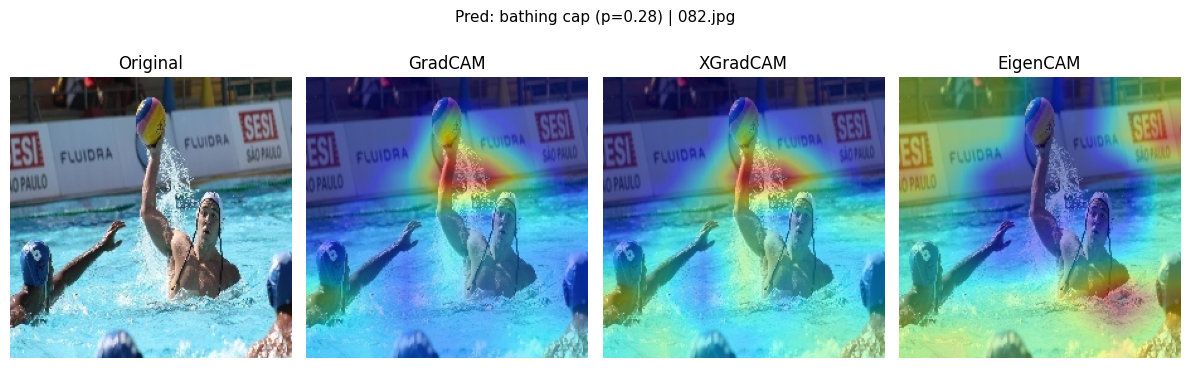

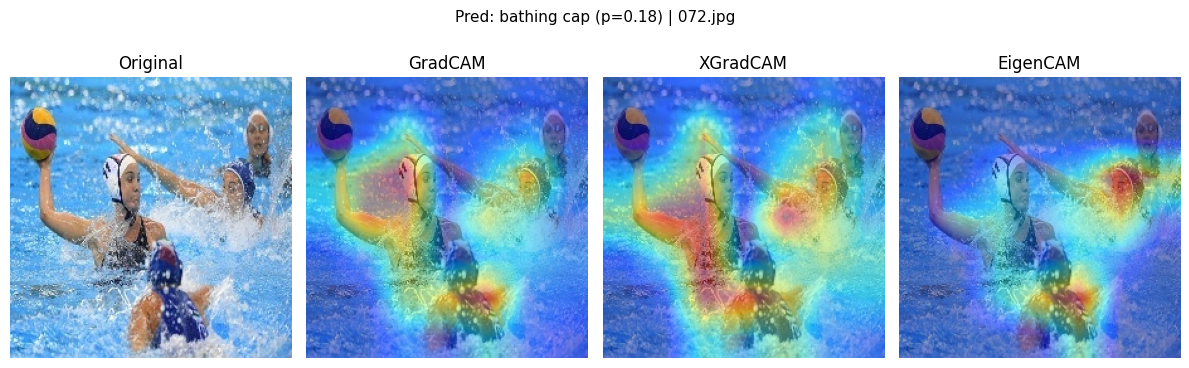

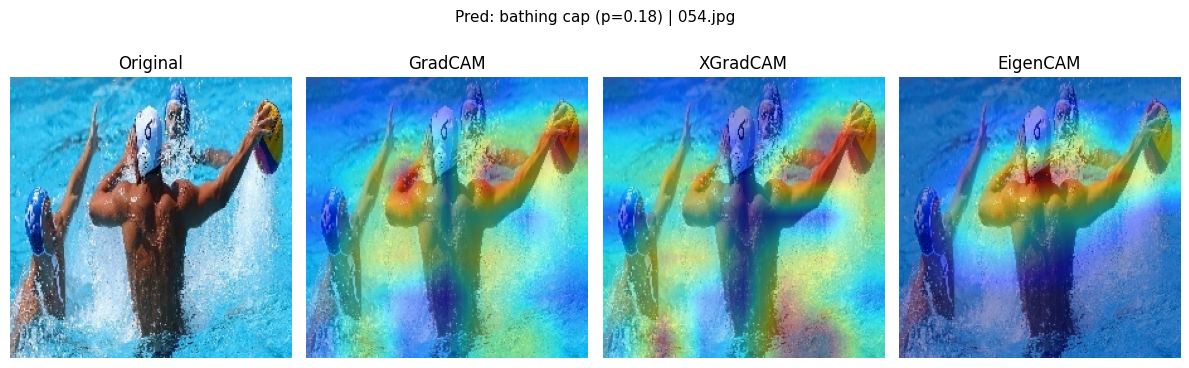

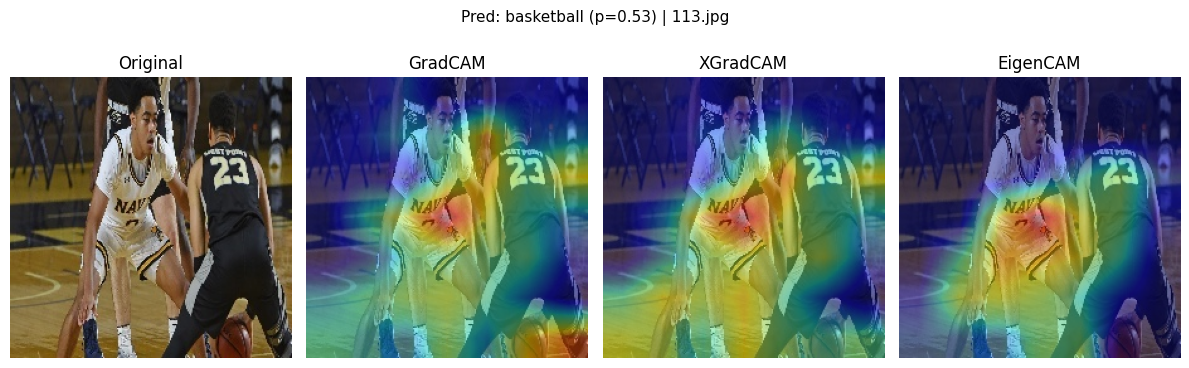

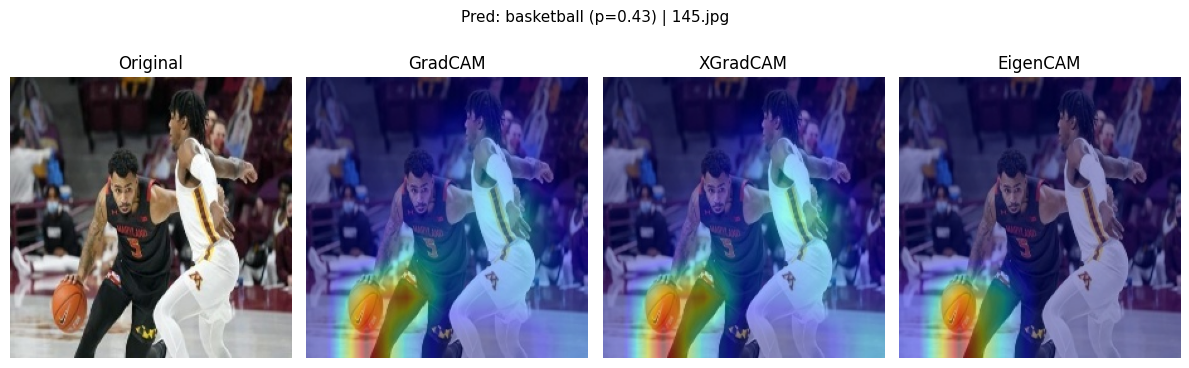

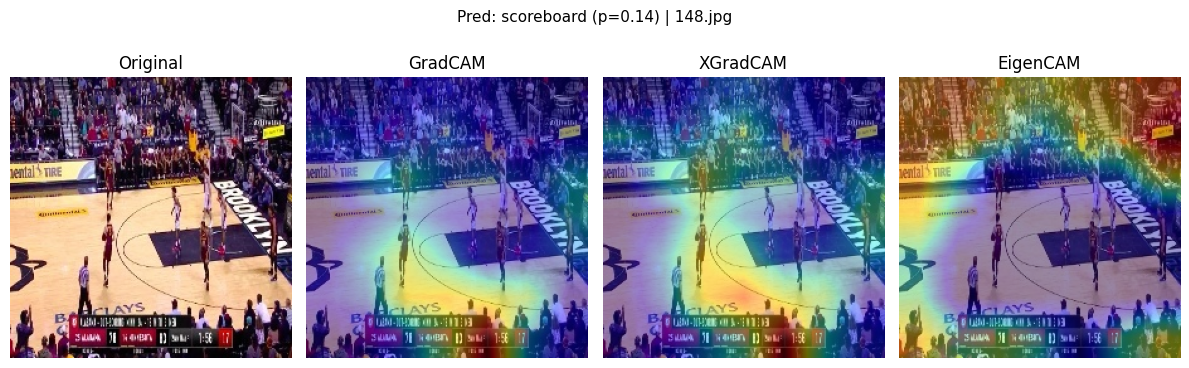

Logged 6 images.


In [27]:
results_log = []

for p in image_paths:
    img = load_rgb(p)
    out = compute_cams_for_image(img)
    pred_label, pred_prob = out["pred_label"], out["pred_prob"]
    cams = out["cams"]

    overlays = {k: overlay_cam_on_image(img, v.cpu().numpy()) for k,v in cams.items()}
    title = f"Pred: {pred_label} (p={pred_prob:.2f}) | {os.path.basename(p)}"
    show_triptych(img, overlays, title)

    results_log.append({
        "file": os.path.basename(p),
        "pred_label": pred_label,
        "pred_prob": round(pred_prob, 3),
        "note_template": {
            "GradCAM":   "What region lit up? (e.g., ball/cap/hoop/jersey)",
            "XGradCAM":  "Sharper/different than GradCAM? What changed?",
            "EigenCAM":  "Broad saliency incl. background or object?"
        }
    })

print("Logged", len(results_log), "images.")

 The above code snippet was generated using GPT-5 on 1/10/25 at 2:03pm.

## Image 1 – Water Polo - 082.jpg

GradCAM: Focuses strongly on the player’s head and the raised arm with the ball. This makes sense since the predicted class is influenced by headgear (bathing cap).

XGradCAM: Similar to GradCAM but sharper around the ball and the hand - better localization.

EigenCAM: Highlights a broader area, including torso and some water splash, not just the head.

Summary: GradCAM and XGradCAM look into to valid cues (caps, ball, head). EigenCAM diffuses attention, mixing player and context.

## Image 2 – Water Polo - 072.jpg

GradCAM: Distributed across players, with strong focus on faces/caps and ball-holding arm.

XGradCAM: More focussed attention on the central player’s cap and ball, though still spills into background water.

EigenCAM: Broader view on multiple players and water regions, less specific to the action.

Summary: Model correctly identifies caps/heads, but attention is noisy. Variants show sharper cues (XGradCAM) vs broader view (EigenCAM).

## Image 3 – Water Polo - 054.jpg

GradCAM: Locks on to the caps and the extended arm holding the ball.

XGradCAM: Again sharper, emphasizing the same head and ball but reducing background noise.

EigenCAM: Includes players’ upper bodies and water, less selective.

Summary: All methods confirm caps/ball are decisive cues.XGradCAM offers clearest focus on the ball-holding region.

## Image 4 – Basketball - 113.jpg

GradCAM: Focus on the defender’s torso/arms and some on the ball handler’s face.

XGradCAM: Sharper around the dribbler’s body and the basketball itself.

EigenCAM: Highlights both players’ silhouettes, spreading more evenly across their bodies.

Summary: Correct sport class predicted; model pays attention to uniforms and players. XGradCAM most precise, EigenCAM emphasizes overall player regions.

## Image 5 – Basketball - 145.jpg

GradCAM: Strong hotspot around the ball near the dribbler’s hand, plus defender’s torso.

XGradCAM: Even sharper on the ball and legs of the dribbler, which are action-relevant.

EigenCAM: Larger region including both players, but still clear signal on the ball.

Summary: Ball is consistently highlighted, which is perfect for basketball. GradCAM/XGradCAM align well, EigenCAM offers broader context.

## Image 6 – Basketball - 148.jpg

GradCAM: Surprisingly attends to the scoreboard overlay at the bottom of the image.

XGradCAM: Same behavior — model may be relying on text/court context.

EigenCAM: Broad attention across the entire frame (crowd, scoreboard, court).

Summary: Misleading attention — the model predicted scoreboard and CAMs confirm it focused on the text overlay instead of the players or ball. Shows a misleading correlation.

## Conclusion

the experiments showed me three things:

* The model is capable of focusing on the right signals (caps, balls, player silhouettes), even if its label space doesn’t exactly match the dataset.

* GradCAM was vague(around important regions), XGradCAM gave sharper and more trustworthy maps, while EigenCAM helped me see the broader regions the network found prominent.

* The scoreboard example highlighted how models can easily latch onto shortcuts that humans would find irrelevant. In domains like sports analytics, this matters as explainability helps uncover biases, guides dataset curation, and ensures trust in how predictions are made.